In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df1=pd.read_csv("borrower_profiles.csv")
df2=pd.read_csv("loan_applications.csv")
print(df1.head())
print(df2.head())

  borrower_id  age state education_level employment_status  years_employed  \
0    BRW-0001   62    CT     High School     Self-Employed               6   
1    BRW-0002   24    CO     High School         Full-Time               4   
2    BRW-0003   50    NC        Bachelor          Contract              22   
3    BRW-0004   43    TX     High School         Full-Time              19   
4    BRW-0005   46    NY     High School         Full-Time              18   

   annual_income  credit_score home_ownership  dependents  \
0          31020           596           Rent           1   
1          40188           543            Own           2   
2          41014           611       Mortgage           0   
3          35036           701       Mortgage           2   
4          44528           715            Own           0   

   existing_monthly_debt  Unnamed: 11  
0                    892          NaN  
1                    869          NaN  
2                   1806          NaN  
3   

In [3]:
#checking for missing values
print(df1.isnull().sum())
print(df2.isnull().sum())

borrower_id                0
age                        0
state                      0
education_level            0
employment_status          0
years_employed             0
annual_income              0
credit_score               0
home_ownership             0
dependents                 0
existing_monthly_debt      0
Unnamed: 11              500
dtype: int64
loan_id             0
borrower_id         0
application_date    0
loan_purpose        0
loan_amount         0
term_months         0
interest_rate       0
monthly_payment     0
dti_ratio           0
loan_status         0
days_delinquent     0
defaulted           0
dtype: int64


In [4]:
#checking for the summary statistics
print(df1.describe())
print(df2.describe())

              age  years_employed  annual_income  credit_score  dependents  \
count  500.000000      500.000000     500.000000    500.000000  500.000000   
mean    44.986000       10.854000   64471.484000    704.952000    1.356000   
std     13.539736        9.301706   28959.837645     97.339157    1.252358   
min     22.000000        0.000000   12549.000000    528.000000    0.000000   
25%     33.000000        3.000000   42968.250000    617.750000    0.000000   
50%     45.000000        8.000000   59282.500000    708.000000    1.000000   
75%     57.000000       17.000000   79780.500000    794.250000    2.000000   
max     68.000000       35.000000  157047.000000    850.000000    4.000000   

       existing_monthly_debt  Unnamed: 11  
count             500.000000          0.0  
mean             1585.166000          NaN  
std              1089.979915          NaN  
min               124.000000          NaN  
25%               788.750000          NaN  
50%              1312.000000     

In [5]:
print(df1.info())
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   borrower_id            500 non-null    object 
 1   age                    500 non-null    int64  
 2   state                  500 non-null    object 
 3   education_level        500 non-null    object 
 4   employment_status      500 non-null    object 
 5   years_employed         500 non-null    int64  
 6   annual_income          500 non-null    int64  
 7   credit_score           500 non-null    int64  
 8   home_ownership         500 non-null    object 
 9   dependents             500 non-null    int64  
 10  existing_monthly_debt  500 non-null    int64  
 11  Unnamed: 11            0 non-null      float64
dtypes: float64(1), int64(6), object(5)
memory usage: 47.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 colu

In [6]:
#merging the two datasets on borrower_id
df=pd.merge(df1, df2, on='borrower_id', how='inner')
print(df.head())



  borrower_id  age state education_level employment_status  years_employed  \
0    BRW-0001   62    CT     High School     Self-Employed               6   
1    BRW-0001   62    CT     High School     Self-Employed               6   
2    BRW-0002   24    CO     High School         Full-Time               4   
3    BRW-0003   50    NC        Bachelor          Contract              22   
4    BRW-0004   43    TX     High School         Full-Time              19   

   annual_income  credit_score home_ownership  dependents  ...  \
0          31020           596           Rent           1  ...   
1          31020           596           Rent           1  ...   
2          40188           543            Own           2  ...   
3          41014           611       Mortgage           0  ...   
4          35036           701       Mortgage           2  ...   

   application_date    loan_purpose loan_amount term_months interest_rate  \
0        08/01/2024        Vacation       16100          

2. SEGMENT ANALYSIS
a)Creating credit score buckets and calculating the default rate for each bucket.

In [7]:
#defining bins and labels for the credit score buckets
bins= [0,549,599,649,699,749,799,850]
labels= ['less than 550','550-599','600-649','650-699','700-749','750-799','800-850']
df['credit_score_bucket']=pd.cut(df['credit_score'], bins=bins, labels=labels, include_lowest=True)
#grouping the data by credit score bucket and calculating the default rate for each bucket
cs_defaults = df.groupby('credit_score_bucket', observed=False)['defaulted'].agg(['mean', 'count']).reset_index()

#formatting the outup to make it readable
cs_defaults['default_rate'] = (cs_defaults['mean'] * 100).round(2).astype(str) + '%'
cs_defaults = cs_defaults.rename(columns={'count': 'total_loans'})

print(cs_defaults[['credit_score_bucket', 'default_rate', 'total_loans']])

  credit_score_bucket default_rate  total_loans
0       less than 550        50.0%           22
1             550-599       48.94%           94
2             600-649       29.03%           93
3             650-699        28.0%           75
4             700-749       16.28%           86
5             750-799        6.82%           88
6             800-850       14.69%          143


b)  Creating DTI range buckets and calculating their default rate

In [8]:
print(df2.describe())


        loan_amount  term_months  interest_rate  monthly_payment   dti_ratio  \
count    601.000000   601.000000     601.000000       601.000000  601.000000   
mean   22148.252912    36.539101      10.641331       948.337654   49.680699   
std    13215.261422    16.898192       2.251153       864.959543   24.113652   
min     2000.000000    12.000000       5.860000        44.140000    7.600000   
25%    10900.000000    24.000000       8.940000       359.860000   32.200000   
50%    20400.000000    36.000000      10.540000       684.870000   48.100000   
75%    32700.000000    48.000000      12.330000      1165.200000   62.400000   
max    49800.000000    60.000000      15.860000      4262.690000  177.400000   

       days_delinquent   defaulted  
count       601.000000  601.000000  
mean         27.036606    0.242928  
std          47.802845    0.429209  
min           0.000000    0.000000  
25%           0.000000    0.000000  
50%           0.000000    0.000000  
75%          30.0000

In [9]:
#defining bin and labels of DTI ratio buckets
dti_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100, np.inf]
dti_labels = ['0-20%', '21-30%', '31-40%', '41-50%', '51-60%', '61-70%', '71-80%', '81-90%', '91-100%', '100%+']

#creating a new column with the DTI ratio buckets
df['dti_bucket'] = pd.cut(df['dti_ratio'], bins=dti_bins, labels=dti_labels)

#Grouping by the new bucket and calculate the default rate average and total count
dti_defaults = df.groupby('dti_bucket', observed=False)['defaulted'].agg(['mean', 'count']).reset_index()

#formatting output to make it readable
dti_defaults['default_rate'] = (dti_defaults['mean'] * 100).round(2).astype(str) + '%'
dti_defaults = dti_defaults.rename(columns={'count': 'total_loans'})

print(dti_defaults[['dti_bucket', 'default_rate', 'total_loans']])

  dti_bucket default_rate  total_loans
0      0-20%       16.67%           48
1     21-30%       12.82%           78
2     31-40%       11.71%          111
3     41-50%        23.4%           94
4     51-60%       32.32%           99
5     61-70%       32.89%           76
6     71-80%       39.53%           43
7     81-90%       33.33%           18
8    91-100%       41.67%           12
9      100%+       36.36%           22


c) Analysisng default rates by employment status

In [10]:
# Re-verify the distribution and default rate by employment status
emp_defaults = df.groupby('employment_status', observed=False)['defaulted'].agg(['mean', 'count']).reset_index()
emp_defaults['default_rate'] = (emp_defaults['mean'] * 100).round(2).astype(str) + '%'
emp_defaults = emp_defaults.rename(columns={'count': 'total_loans'}).sort_values('mean', ascending=False)
print(emp_defaults[['employment_status', 'default_rate', 'total_loans']])

  employment_status default_rate  total_loans
2         Part-Time       27.69%           65
4     Self-Employed       24.76%          105
1         Full-Time       23.93%          305
3           Retired       23.33%           60
0          Contract       22.73%           66


d) analysing according to the loan purpose

In [11]:
#Group by loan_purpose and calculate the default rate (mean) and total count
purpose_defaults = df.groupby('loan_purpose', observed=False)['defaulted'].agg(['mean', 'count']).reset_index()

# Formatting the default rate as a percentage for readability
purpose_defaults['default_rate'] = (purpose_defaults['mean'] * 100).round(2).astype(str) + '%'

# Rename the count column and sort the results from highest default rate to lowest
purpose_defaults = purpose_defaults.rename(columns={'count': 'total_loans'}).sort_values('mean', ascending=False)

# Display the final segment analysis
print(purpose_defaults[['loan_purpose', 'default_rate', 'total_loans']])

         loan_purpose default_rate  total_loans
9             Wedding       32.14%           56
4    Home Improvement       28.57%           70
0           Auto Loan       27.12%           59
1       Business Loan       24.14%           58
3           Education       22.64%           53
8            Vacation       22.58%           62
5      Major Purchase       22.06%           68
2  Debt Consolidation       21.57%           51
7              Moving       21.43%           56
6    Medical Expenses       20.59%           68


3.CORRELATION ANALYSIS
using a correlation heatmap

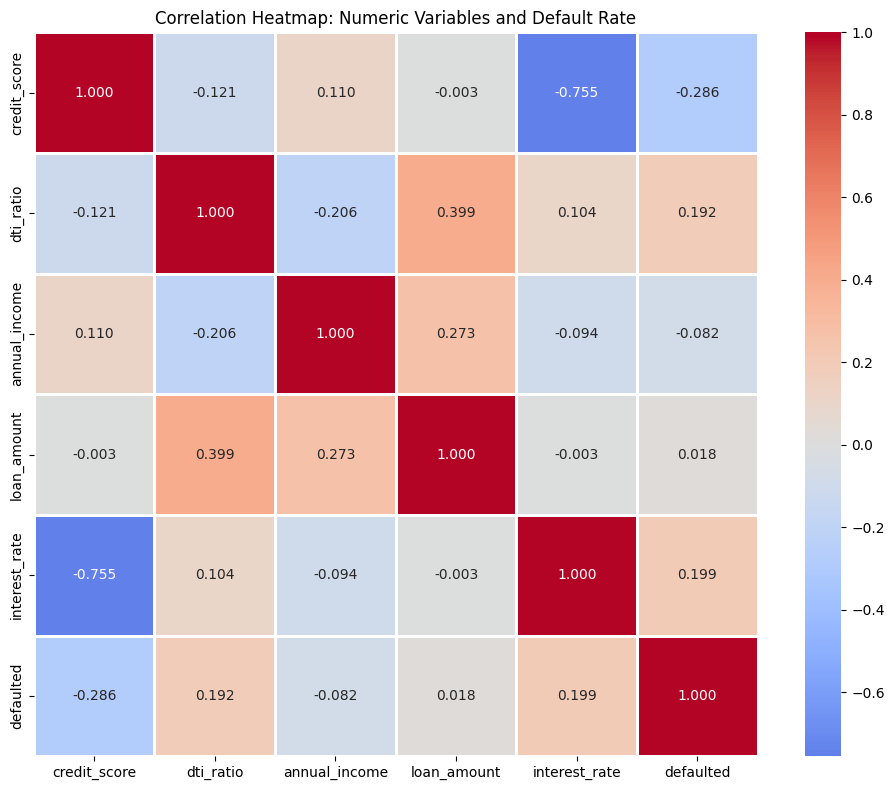


Correlation with Default Rate:
defaulted        1.000000
interest_rate    0.198930
dti_ratio        0.192454
loan_amount      0.018116
annual_income   -0.081546
credit_score    -0.286394
Name: defaulted, dtype: float64


In [12]:
# Select numeric columns relevant for correlation analysis
numeric_cols = ['credit_score', 'dti_ratio', 'annual_income', 'loan_amount', 'interest_rate', 'defaulted']

# Calculate correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True, linewidths=1)
plt.title('Correlation Heatmap: Numeric Variables and Default Rate')
plt.tight_layout()
plt.show()

# Display correlations with defaulted variable specifically
default_correlations = correlation_matrix['defaulted'].sort_values(ascending=False)
print("\nCorrelation with Default Rate:")
print(default_correlations)

C:\Users\brand\AppData\Local\Temp\ipykernel_11520\504802239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='credit_score_bucket', y='mean_pct', data=cs_defaults, order=labels, palette='Blues_d')


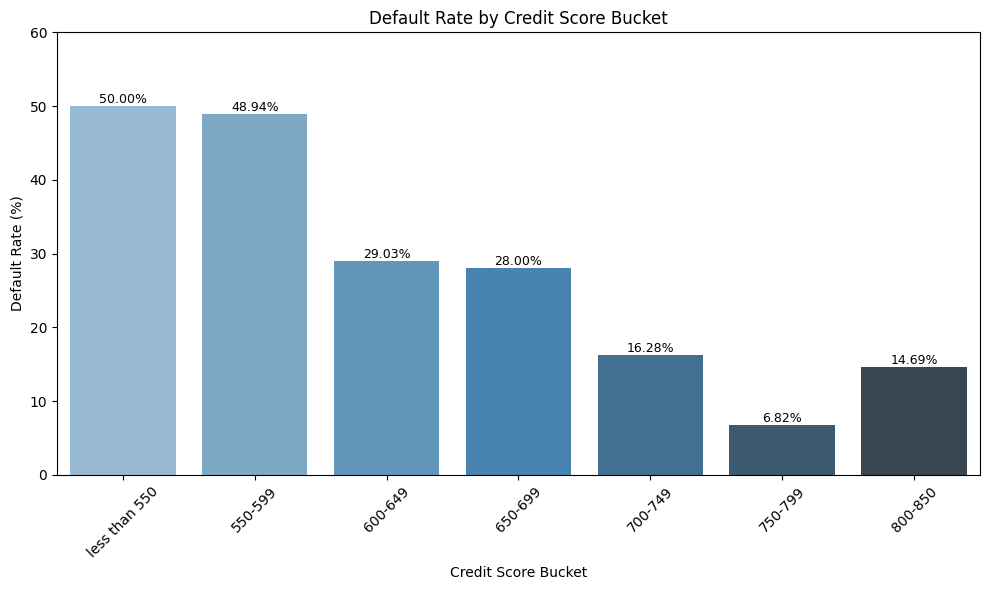

In [13]:
# Plot default rate by credit score bucket
cs_defaults['mean_pct'] = cs_defaults['mean'] * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='credit_score_bucket', y='mean_pct', data=cs_defaults, order=labels, palette='Blues_d')
ax.set_xlabel('Credit Score Bucket')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Credit Score Bucket')
ax.set_ylim(0, cs_defaults['mean_pct'].max() * 1.2)

# annotate bars with percentage labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()